# IT0001 — Label Encoding
**Member 1 — Preprocessing Technique: Label Encoding**

Course: IT2011 — Artificial Intelligence and Machine Learning (SLIIT, Year 2, Semester 1)

This notebook is **fully independent**: it loads the raw dataset directly and performs its own
missing-value handling and its own encoding technique from start to finish. It does not depend
on any other member's notebook.

## 1. Introduction

**Label Encoding** converts each categorical value in a column into a single integer
(e.g. `'x' -> 0`, `'b' -> 1`, `'s' -> 2`, ...). It is simple, fast, and keeps the number of
columns unchanged, which makes it a natural fit for **tree-based models** (Decision Tree,
Random Forest, Gradient Boosting) that split on thresholds rather than assuming any distance
or ordering between values. It is used here as the primary preprocessing technique for
this member's assigned model.

## 2. Load Raw Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/raw/mushrooms.csv')
print("Shape:", df.shape)
df.head()

Shape: (8124, 23)


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


## 3. Handle Missing Values & Drop Useless Column

**Missing-value strategy chosen: mode imputation.**
The `stalk-root` column uses `'?'` for missing entries (~30% missing). Mode imputation
(replacing missing values with the most frequent category) is chosen here because it is simple,
keeps all 8,124 rows (no data loss), and label encoding will map the imputed mode to a plain
integer just like every other value — no extra column or complexity is introduced.

In [2]:
df = df.replace('?', np.nan)

print("Missing value counts per column:")
print(df.isnull().sum())
print()
print("Missing value percentage per column:")
print((df.isnull().sum() / len(df) * 100).round(2))

# veil-type has only 1 unique value across the whole dataset -> no predictive
# information at all, so every member drops it after noting this.
print()
print("veil-type unique values:", df['veil-type'].unique())
df = df.drop(columns=['veil-type'])

# Strategy: mode imputation for stalk-root (keeps all rows, simplest for label encoding)
mode_value = df['stalk-root'].mode()[0]
print("Mode of stalk-root:", mode_value)
df['stalk-root'] = df['stalk-root'].fillna(mode_value)

print()
print("Missing values remaining:", df.isnull().sum().sum())

Missing value counts per column:
class                          0
cap-shape                      0
cap-surface                    0
cap-color                      0
bruises                        0
odor                           0
gill-attachment                0
gill-spacing                   0
gill-size                      0
gill-color                     0
stalk-shape                    0
stalk-root                  2480
stalk-surface-above-ring       0
stalk-surface-below-ring       0
stalk-color-above-ring         0
stalk-color-below-ring         0
veil-type                      0
veil-color                     0
ring-number                    0
ring-type                      0
spore-print-color              0
population                     0
habitat                        0
dtype: int64

Missing value percentage per column:
class                        0.00
cap-shape                    0.00
cap-surface                  0.00
cap-color                    0.00
bruises              

/var/folders/ln/lpsmr0qd3673cmmw327l0g1m0000gn/T/ipykernel_27610/4177635864.py:18: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['stalk-root'].fillna(mode_value, inplace=True)


## 4. Apply Label Encoding

`sklearn.preprocessing.LabelEncoder` is applied independently to every remaining feature
column (target `class` is handled separately in Section 5). The letter -> number mapping is
printed for each column so it is fully transparent and reproducible.

In [3]:
from sklearn.preprocessing import LabelEncoder

feature_cols = [c for c in df.columns if c != 'class']
label_encoders = {}

for col in feature_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"{col}: {mapping}")

cap-shape: {'b': np.int64(0), 'c': np.int64(1), 'f': np.int64(2), 'k': np.int64(3), 's': np.int64(4), 'x': np.int64(5)}
cap-surface: {'f': np.int64(0), 'g': np.int64(1), 's': np.int64(2), 'y': np.int64(3)}
cap-color: {'b': np.int64(0), 'c': np.int64(1), 'e': np.int64(2), 'g': np.int64(3), 'n': np.int64(4), 'p': np.int64(5), 'r': np.int64(6), 'u': np.int64(7), 'w': np.int64(8), 'y': np.int64(9)}
bruises: {'f': np.int64(0), 't': np.int64(1)}
odor: {'a': np.int64(0), 'c': np.int64(1), 'f': np.int64(2), 'l': np.int64(3), 'm': np.int64(4), 'n': np.int64(5), 'p': np.int64(6), 's': np.int64(7), 'y': np.int64(8)}
gill-attachment: {'a': np.int64(0), 'f': np.int64(1)}
gill-spacing: {'c': np.int64(0), 'w': np.int64(1)}
gill-size: {'b': np.int64(0), 'n': np.int64(1)}
gill-color: {'b': np.int64(0), 'e': np.int64(1), 'g': np.int64(2), 'h': np.int64(3), 'k': np.int64(4), 'n': np.int64(5), 'o': np.int64(6), 'p': np.int64(7), 'r': np.int64(8), 'u': np.int64(9), 'w': np.int64(10), 'y': np.int64(11)}
sta

In [4]:
print("Shape after label encoding:", df.shape)
df.head()

Shape after label encoding: (8124, 22)


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,5,2,4,1,6,1,0,1,4,...,2,2,7,7,2,1,4,2,3,5
1,e,5,2,9,1,0,1,0,0,4,...,2,2,7,7,2,1,4,3,2,1
2,e,0,2,8,1,3,1,0,0,5,...,2,2,7,7,2,1,4,3,2,3
3,p,5,3,8,1,6,1,0,1,5,...,2,2,7,7,2,1,4,2,3,5
4,e,5,2,3,0,5,1,1,0,4,...,2,2,7,7,2,1,0,3,0,1


**Note:** Label encoding implies a false ordering between categories (e.g. it says
`cap-shape` value 2 > value 1), which is not meaningful for these nominal categories. This is
generally a problem for distance-based or linear models, but **tree-based models split on
thresholds** (is feature <= X?) rather than treating the numbers as magnitudes, so the false
ordering does not hurt them. This is why label encoding is paired with tree-based models.

## 5. Encode Target Variable

In [5]:
df['class'] = df['class'].map({'e': 0, 'p': 1})
print(df['class'].value_counts())
print()
print("Class balance (%):")
print((df['class'].value_counts(normalize=True) * 100).round(2))

class
0    4208
1    3916
Name: count, dtype: int64

Class balance (%):
class
0    51.8
1    48.2
Name: proportion, dtype: float64


## 6. EDA Visualization

A correlation heatmap of the label-encoded feature matrix (including the target), and a
before/after shape comparison.

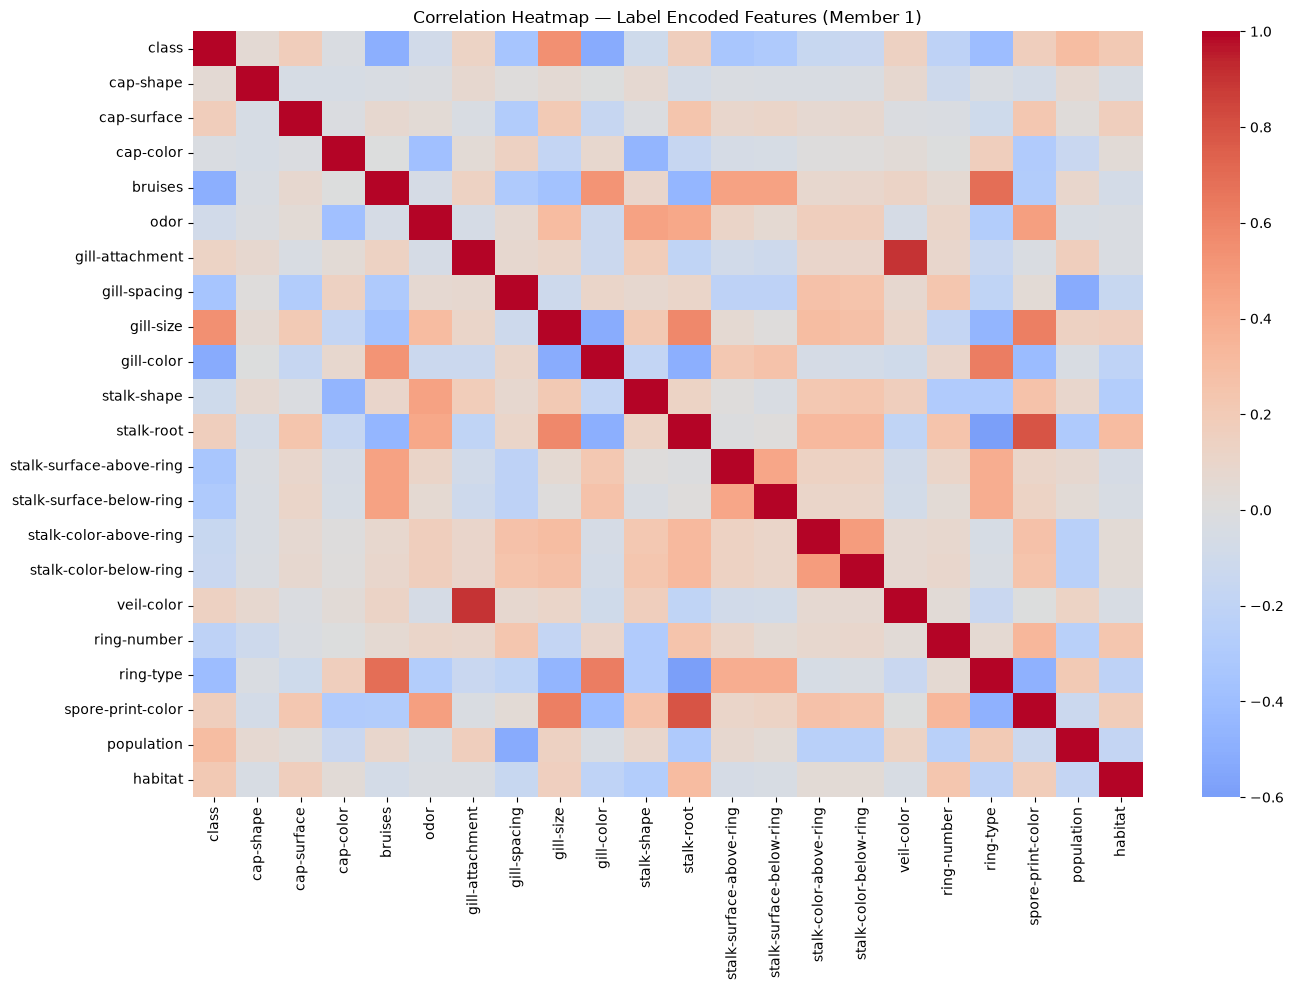

In [6]:
import os
os.makedirs('../results/eda_visualizations', exist_ok=True)

plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Heatmap — Label Encoded Features (Member 1)')
plt.tight_layout()
plt.savefig('../results/eda_visualizations/M1_label_encoding.png', dpi=150)
plt.show()

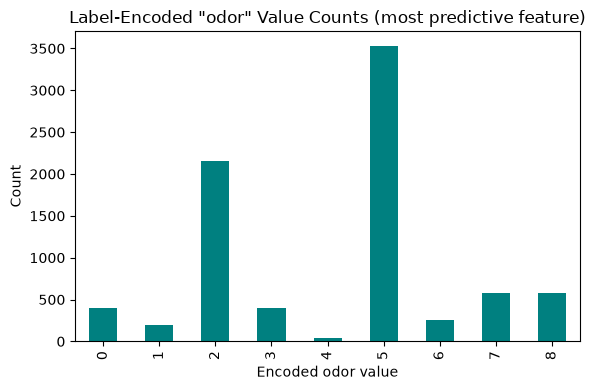

In [7]:
df['odor'].value_counts().sort_index().plot(kind='bar', figsize=(6,4), color='teal')
plt.title('Label-Encoded "odor" Value Counts (most predictive feature)')
plt.xlabel('Encoded odor value')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## 7. Save Output

In [8]:
os.makedirs('../results/outputs', exist_ok=True)
df.to_csv('../results/outputs/step_M1_label_encoded.csv', index=False)
print("Saved: ../results/outputs/step_M1_label_encoded.csv")
print("Final shape:", df.shape)

Saved: ../results/outputs/step_M1_label_encoded.csv
Final shape: (8124, 22)
